In [4]:
import scanpy as sc
import pandas as pd
from pathlib import Path
import os

# --- paths (edit the two folders) ---
base_dir   = Path("/home/ext_sana_noor_astraeabio_com/ext_hd/chiba")
adatas_dir = base_dir / "out_july2025_xenium/script01_adatas"                        # .h5ad files (one per core)
rctd_dir   = base_dir / "rctd_data_prep/final_outputs_rctd/rctd_outputs_with_scores"    # where *_scores_* and *_weights_* live
out_dir    = base_dir / "adatas_with_rctd"; out_dir.mkdir(exist_ok=True)



In [5]:
score_files = os.listdir(rctd_dir)
score_files

['rctd_results_object_adata_GBM5-Edge.rds',
 'rctd_results_weights_adata_GBM2-Core.csv',
 'rctd_results_object_adata_GBM6-Edge.rds',
 'rctd_results_weights_adata_GBM2-Edge.csv',
 'rctd_results_object_adata_Oligo5_Edge.rds',
 'rctd_results_object_adata_AA1_Core.rds',
 'rctd_results_scores_adata_Oligo4_Core.csv',
 'rctd_results_weights_adata_GBM9-Edge.csv',
 'rctd_results_weights_adata_GBM5-Core.csv',
 'rctd_results_object_adata_OligoGr3_Core.rds',
 'rctd_results_object_adata_GBM8-Edge.rds',
 'rctd_results_weights_adata_AA3_Edge.csv',
 'rctd_results_scores_adata_Control_2.csv',
 'rctd_results_scores_adata_Control_1.csv',
 'rctd_results_weights_adata_Oligo4_Edge.csv',
 'rctd_results_weights_adata_AA1_Edge.csv',
 'rctd_results_scores_adata_Oligo3__Core.csv',
 'rctd_results_weights_adata_AA2_Edge.csv',
 'rctd_results_weights_adata_Control_2.csv',
 'rctd_results_object_adata_GBM2-Core.rds',
 'rctd_results_weights_adata_Oligo4_Core.csv',
 'rctd_results_weights_adata_GBM6-Core.csv',
 'rctd_res

In [6]:
# --- helpers for exact CSV schema ---
def load_scores(core):
    fp = rctd_dir / f"rctd_results_scores_{core}.csv"
    if not fp.exists():
        return None
    df = pd.read_csv(fp)
    # has "pixel_id", "singlet score" (and maybe "min score")
    cols = {c: c.lower().strip() for c in df.columns}
    df.rename(columns=cols, inplace=True)
    # standard names
    if "pixel_id" not in df.columns:
        # assume first column is id if not present
        df.rename(columns={df.columns[0]: "pixel_id"}, inplace=True)
    if "singlet score" in df.columns:
        df.rename(columns={"singlet score": "rctd_singlet_score"}, inplace=True)
    if "min score" in df.columns:
        df.rename(columns={"min score": "rctd_min_score"}, inplace=True)
    return df[["pixel_id"] + [c for c in df.columns if c.startswith("rctd_")]]

def load_weights(core):
    fp = rctd_dir / f"rctd_results_weights_{core}.csv"
    if not fp.exists():
        return None
    # weights file has cell types as rows, pixel IDs as columns
    w = pd.read_csv(fp, index_col=0)
    # transpose: rows = pixel_id, cols = cell types
    if w.shape[0] < w.shape[1]:
        w = w.T
    # row-normalize to be safe
    w = w.div(w.sum(axis=1), axis=0).fillna(0.0)
    # compute dominant cell type per pixel
    dom_ct = w.idxmax(axis=1).rename("rctd_cell_type")
    return w, dom_ct



In [7]:
# --- main loop ---
for ad_fp in adatas_dir.glob("*.h5ad"):
    core = ad_fp.stem
    print(f"\n>>> Processing {core}")

    ad = sc.read_h5ad(ad_fp)

    # 1) load scores
    scores = load_scores(core)
    if scores is not None:
        scores = scores.set_index("pixel_id")
    else:
        print("  (no scores file found)")

    # 2) load weights (+ dominant label)
    res = load_weights(core)
    if res is None:
        print("  no weights file found — skipping this core")
        continue
    W, dominant = res
    # keep only obs that exist in the AnnData
    common = ad.obs_names.intersection(W.index.astype(str))
    if len(common) == 0:
        print("  no overlapping pixel IDs between AnnData and weights; check IDs")
        continue

    # align and join to .obs
    ad.obs = ad.obs.copy()
    # add dominant label
    ad.obs.loc[common, "rctd_cell_type"] = dominant.loc[common].astype("category")

    # add one weight column per cell type (optional but handy for plotting)
    for ct in W.columns:
        colname = f"rctd_wt_{ct}"
        ad.obs.loc[common, colname] = W.loc[common, ct].astype("float32")

    # add scores (if present)
    if scores is not None:
        s_common = ad.obs_names.intersection(scores.index.astype(str))
        for col in scores.columns:
            ad.obs.loc[s_common, col] = scores.loc[s_common, col].values

    # save updated AnnData
    out_fp = out_dir / f"{core}_with_rctd.h5ad"
    ad.write(out_fp)
    print(f" wrote: {out_fp}")



>>> Processing adata_GBM10-Edge
  no overlapping pixel IDs between AnnData and weights; check IDs

>>> Processing adata_Oligo2_Edge


  no overlapping pixel IDs between AnnData and weights; check IDs

>>> Processing adata_Oligo5_Edge
 wrote: /home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd/adata_Oligo5_Edge_with_rctd.h5ad

>>> Processing adata_GBM4-Edge
 wrote: /home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd/adata_GBM4-Edge_with_rctd.h5ad

>>> Processing adata_GBM2-Core
 wrote: /home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd/adata_GBM2-Core_with_rctd.h5ad

>>> Processing adata_GBM8-Core
 wrote: /home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd/adata_GBM8-Core_with_rctd.h5ad

>>> Processing adata_AA1_Edge
 wrote: /home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd/adata_AA1_Edge_with_rctd.h5ad

>>> Processing adata_GBM6-Edge
 wrote: /home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd/adata_GBM6-Edge_with_rctd.h5ad

>>> Processing adata_OligoGr3_Edge
 wrote: /home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd/adata_O

In [8]:
import scanpy as sc, pandas as pd
from pathlib import Path

base = Path("/home/ext_sana_noor_astraeabio_com/ext_hd/chiba")
core  = "adata_GBM5-Core"   # <-- pick one that failed

ad = sc.read_h5ad(base/"out_july2025_xenium/script01_adatas"/f"{core}.h5ad")
W  = pd.read_csv(base/"rctd_data_prep/final_outputs_rctd/rctd_outputs_with_scores"/f"rctd_results_weights_{core}.csv", index_col=0)

# weights file: rows=cell types, cols=pixel ids -> transpose to pixel x celltype
if W.shape[0] < W.shape[1]:
    W = W.T

print("examples from AnnData:", list(ad.obs_names[:5]))
print("examples from weights:", list(W.index[:5]))

print("exact overlap:", len(ad.obs_names.intersection(W.index.astype(str))))


examples from AnnData: ['fcflagcf-1', 'fhbdahai-1', 'ajhkeihn-1', 'iapchgmn-1', 'fcfkjldb-1']
examples from weights: ['MES-like', 'OPC-like', 'TAM-BDM', 'AC-like', 'Mural cell']
exact overlap: 0


In [12]:
# === Attach RCTD to remaining cores — try transpose first (minimal fixes) ===
import numpy as np, pandas as pd, scanpy as sc
from pathlib import Path

ROOT   = Path("/home/ext_sana_noor_astraeabio_com/ext_hd/chiba")
RCTD   = ROOT / "rctd_data_prep/final_outputs_rctd/rctd_outputs_with_scores"
OUT    = ROOT / "adatas_with_rctd"; OUT.mkdir(exist_ok=True)
SEARCH = ROOT  # search for .h5ad recursively

# ---------- helpers ----------
def load_weights(core):
    fp = RCTD / f"rctd_results_weights_{core}.csv"
    if not fp.exists(): return None
    return pd.read_csv(fp, index_col=0)

def load_scores(core):
    fp = RCTD / f"rctd_results_scores_{core}.csv"
    if not fp.exists(): return None
    S = pd.read_csv(fp)
    S.columns = [c.lower().strip() for c in S.columns]
    if "pixel_id" not in S.columns:
        # if first col looks like IDs, treat it as pixel_id
        S.rename(columns={S.columns[0]: "pixel_id"}, inplace=True)
    if "singlet score" in S.columns:
        S.rename(columns={"singlet score": "rctd_singlet_score"}, inplace=True)
    if "min score" in S.columns:
        S.rename(columns={"min score": "rctd_min_score"}, inplace=True)
    return S.set_index("pixel_id")

def _overlap(a_idx: pd.Index, b_idx: pd.Index) -> int:
    return len(a_idx.intersection(b_idx))

def _variant_indices(idx: pd.Index, mode: str):
    s = idx.astype(str)
    if mode == "as_is":    return pd.Index(s)
    if mode == "add_m1":   return pd.Index(s + "-1")
    if mode == "drop_m1":  return pd.Index([x[:-2] if x.endswith("-1") else x for x in s])
    raise ValueError

def best_match(W_rows: pd.Index, ad_rows: pd.Index):
    """Try minimal variants (as_is, add/drop -1) and return the best mapping (name_on_W, name_on_AD, overlap)."""
    best = ("as_is", "as_is", 0)
    for vW in ("as_is", "add_m1", "drop_m1"):
        Wi = _variant_indices(W_rows, vW)
        for vA in ("as_is", "add_m1", "drop_m1"):
            Ai = _variant_indices(ad_rows, vA)
            n  = _overlap(Wi, Ai)
            if n > best[2]:
                best = (vW, vA, n)
    return best

def orient_weights_for(adata, W_raw):
    """Try W_raw 'as-is' and transposed; pick orientation with larger overlap vs adata.obs_names (with minimal -1 fix)."""
    candidates = []
    # candidate A: assume rows are pixel ids already
    A = W_raw
    if A.shape[0] >= 1 and A.shape[1] >= 1:
        vW, vA, n = best_match(A.index, adata.obs_names)
        candidates.append(("as_is", A, vW, vA, n))
    # candidate B: transpose
    B = W_raw.T
    if B.shape[0] >= 1 and B.shape[1] >= 1:
        vW, vA, n = best_match(B.index, adata.obs_names)
        candidates.append(("T", B, vW, vA, n))
    # choose
    if not candidates: return None, None, None, 0
    cand = max(candidates, key=lambda x: x[4])
    return cand  # (tag, W_oriented, vW, vA, n)

def align_index(W: pd.DataFrame, ad: sc.AnnData, vW: str, vA: str):
    Wi = _variant_indices(W.index, vW)
    Ai = _variant_indices(ad.obs_names, vA)
    inter = Wi.intersection(Ai)
    if len(inter) == 0: return None, None
    # map back to original names
    W_map = pd.Series(W.index.values, index=Wi)
    A_map = pd.Series(ad.obs_names.values, index=Ai)
    w_keep = W_map.loc[inter].values
    a_keep = A_map.loc[inter].values
    Walign = W.loc[w_keep].copy()
    Walign.index = a_keep
    return Walign, inter

# ---------- figure out remaining cores ----------
rctd_cores = [p.stem.replace("rctd_results_weights_", "") for p in RCTD.glob("rctd_results_weights_*.csv")]
done_cores = set(p.stem.replace("_with_rctd", "") for p in OUT.glob("*_with_rctd.h5ad"))

h5ad_map = {}
for p in SEARCH.rglob("*.h5ad"):
    core = p.stem.replace("_with_rctd", "")
    h5ad_map[core] = p

remaining = [c for c in rctd_cores if (c in h5ad_map and c not in done_cores)]
print(f"Remaining cores: {len(remaining)}")

attached, skipped = [], []

# ---------- main loop ----------
for core in sorted(remaining):
    print(f"\n>>> {core}")
    ad = sc.read_h5ad(h5ad_map[core])
    Wraw = load_weights(core)
    if Wraw is None:
        print("   no weights CSV"); skipped.append(core); continue

    tag, Wori, vW, vA, n = orient_weights_for(ad, Wraw)
    print(f"   orientation: {tag}, overlap: {n}")
    if n == 0:
        print("   0 overlap even after transpose/minimal -1 fix → skip")
        skipped.append(core); continue

    # normalize rows (mixture proportions)
    Wori = Wori.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    Wori = Wori.div(Wori.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

    Walign, inter = align_index(Wori, ad, vW, vA)
    if Walign is None:
        print("   failed to align"); skipped.append(core); continue

    # write weights & dominant label only for matched rows
    ad.obs.loc[Walign.index, "rctd_cell_type"] = Walign.idxmax(axis=1).astype("category")
    for ct in Walign.columns:
        ad.obs.loc[Walign.index, f"rctd_wt_{ct}"] = Walign[ct].astype("float32").values

    # scores: try as-is and transposed if pixel_id not index
    S = load_scores(core)
    if S is not None and not S.index.isin(inter).any():
        # try transpose if their "pixel_id" was actually columns
        if "pixel_id" in S.columns:
            S = S.set_index("pixel_id")
        else:
            S = S.T
            if "pixel_id" in S.columns:
                S = S.set_index("pixel_id")
        # final reindex to matched set
    if S is not None:
        Sadd = S.reindex(Walign.index)  # align to AnnData matched rows
        ad.obs = ad.obs.join(Sadd, how="left")

    out_fp = OUT / f"{core}_with_rctd.h5ad"
    ad.write(out_fp)
    print(f"   ✓ wrote {out_fp}")
    attached.append(core)

print("\nDONE")
print("attached:", len(attached), attached)
print("skipped :", len(skipped), skipped)


Remaining cores: 0

DONE
attached: 0 []
skipped : 0 []


#### Assign colors

In [10]:
colors_palette = [
    '#ebac23', #\n",
    '#b80058', #lipstick 0,140,249 \n",
    '#008cf9', #azure 0,110,0 \n",
    '#006e00', #green 0,187,173 \n",
    '#00bbad', #caribbean 209,99,230 \n",
    '#d163e6', #lavender 178,69,2 \n",
    '#b24502', #brown 255,146,135 \n",
    '#ff9287', #coral 89,84,214 \n",
    '#5954d6', #indigo 0,198,248 \n",
    '#00c6f8', #turquoise 135,133,0 \n",
    '#878500', #olive 0,167,108 \n",
    '#00a76c', #jade 189,189,189 \n",
    '#274d52', #plantation 199,162,166 \n",
    '#c7a2a6', #eunry 129,139,112 \n",
    '#818b70', #battleship 96,78,60 \n",
    '#604e3c', #kabul 140,159,183 \n",
    '#8c9fb7', #balihai 121,104,128 \n",
    '#796880', #rum,\n",
    '#56641a', #fernfrond 192,175,251 \n",
    '#c0affb', #perfume 230,161,118 \n",
    '#e6a176', #apricot 0,103,138 \n",
    '#00678a', #orient 152,68,100 \n",
    '#984464', #vinrouge 94,204,171 \n",
    '#5eccab', #downy\n",
    '#bdbdbd'] #gray\n"

### Load all updated AnnData, concat, optional score filter

In [14]:
def get_category(core):
    if core.startswith("GBM"):
        return "GBM"
    elif core.startswith("AA"):
        return "AA"
    elif core.startswith("OL"):
        return "Oligo"
    elif "control" in core.lower():
        return "Control"
    else:
        return "Unknown"


adatas = []
for p in sorted(OUT.glob("*_with_rctd.h5ad")):
    ad = sc.read_h5ad(p)
    core = p.stem.replace("_with_rctd", "")
    ad.obs["core"] = core
    ad.obs["category"] = get_category(core)
    adatas.append(ad)

adata_all = sc.concat(adatas, join="outer", label="batch", index_unique=None)
print(adata_all)



AnnData object with n_obs × n_vars = 169574 × 361
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_location_px', 'y_location_px', 'y_tma', 'x_tma', 'Samples', 'Region', 'Type', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_15_genes', 'pct_counts_in_top_20_genes', 'n_counts', 'leiden', 'rctd_cell_type', 'rctd_wt_MES-like', 'rctd_wt_OPC-like', 'rctd_wt_TAM-BDM', 'rctd_wt_AC-like', 'rctd_wt_Mural cell', 'rctd_wt_DC', 'rctd_wt_TAM-MG', 'rctd_wt_Mono', 'rctd_wt_Oligodendrocyte', 'rctd_wt_Endothelial', 'rctd_wt_NPC-like', 'rctd_wt_CD4_CD8', 'rctd_wt_OPC', 'rctd_wt_Mast', 'rctd_wt_B cell', 'rctd_wt_Plasma B', 'rctd_wt_NK', 'rctd_wt_Astrocyte', 'rctd_wt_RG', 'rctd_wt_Neuron', 'rctd_wt_Neutrophil', 'core', '

In [ ]:
# --- Use your known label column ---
label_col = "rctd_cell_type"

# Optional: score filter
SCORE_COL = "singlet_score"  # or None if you don’t want to filter
SCORE_MIN = 0.8              # adjust threshold if too strict

if SCORE_COL and SCORE_COL in adata_all.obs.columns and SCORE_MIN is not None:
    keep = adata_all.obs[SCORE_COL] > SCORE_MIN
    print(f"Score filter: kept {int(keep.sum())} / {adata_all.n_obs}")
    adata_all = adata_all[keep].copy()

# Build df and pivot
df = adata_all.obs[["core", label_col]].rename(columns={label_col: "top"}).copy()

core_props = (
    df.assign(_top=df["top"])
      .pivot_table(index="core", columns="_top", aggfunc="size", fill_value=0)
)
core_props = (core_props.div(core_props.sum(axis=1), axis=0) * 100).round(2)

print(core_props)


Score filter: kept 69 / 69
_top                 AC-like  Astrocyte  Endothelial  MES-like  Mural cell  \
core                                                                         
adata_AA2_Edge           0.0       0.00         7.14       0.0        0.00   
adata_GBM10-Core         0.0       0.00         0.00     100.0        0.00   
adata_GBM10-Edge         0.0       0.00         0.00      75.0        0.00   
adata_GBM5-Core         25.0       0.00        25.00      25.0        0.00   
adata_Oligo2_Edge        5.0      20.00        10.00      10.0       15.00   
adata_Oligo3_Edge       12.5       6.25         6.25      25.0        6.25   
adata_OligoGr3_Core      0.0       0.00         0.00      10.0       50.00   

_top                 NPC-like  OPC-like  Oligodendrocyte     RG  TAM-MG  
core                                                                     
adata_AA2_Edge            0.0       0.0            35.71  35.71   21.43  
adata_GBM10-Core          0.0       0.0         

/tmp/ipykernel_3785/1964149185.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="core", columns="_top", aggfunc="size", fill_value=0)


In [39]:
df = adata_all.obs[["core", "rctd_cell_type"]].rename(columns={"rctd_cell_type":"top"}).copy()

core_props = (
    df[df["top"].notna()]                      # only entries with labels contribute
      .assign(_top=lambda x: x["top"])
      .pivot_table(index="core", columns="_top", aggfunc="size", fill_value=0)
)

# reindex to include every core, filling missing with 0
all_cores = sorted(adata_all.obs["core"].unique())
core_props = core_props.reindex(all_cores, fill_value=0)
core_props = (core_props.div(core_props.sum(axis=1).replace(0,1), axis=0) * 100).round(2)
print(core_props)


_top                 AC-like  Astrocyte  Endothelial  MES-like  Mural cell  \
core                                                                         
adata_AA2_Edge           0.0       0.00         7.14       0.0        0.00   
adata_GBM10-Core         0.0       0.00         0.00     100.0        0.00   
adata_GBM10-Edge         0.0       0.00         0.00      75.0        0.00   
adata_GBM5-Core         25.0       0.00        25.00      25.0        0.00   
adata_Oligo2_Edge        5.0      20.00        10.00      10.0       15.00   
adata_Oligo3_Edge       12.5       6.25         6.25      25.0        6.25   
adata_OligoGr3_Core      0.0       0.00         0.00      10.0       50.00   

_top                 NPC-like  OPC-like  Oligodendrocyte     RG  TAM-MG  
core                                                                     
adata_AA2_Edge            0.0       0.0            35.71  35.71   21.43  
adata_GBM10-Core          0.0       0.0             0.00   0.00    0.00  
a

/tmp/ipykernel_3785/3095913159.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="core", columns="_top", aggfunc="size", fill_value=0)


In [40]:
print("Cores:", sorted(df["core"].unique()))
print("N cores:", df["core"].nunique())
print("Label mode:", "merged" if top_assign.name=="top_merged" else "raw")
print("Labels:", sorted(pd.Index(top_assign).dropna().unique())[:25], "...")
print("Score filter used:", SCORE_COL, SCORE_MIN if SCORE_COL in df.columns else None)
print("Rows kept:", len(df))


Cores: ['adata_AA2_Edge', 'adata_GBM10-Core', 'adata_GBM10-Edge', 'adata_GBM5-Core', 'adata_Oligo2_Edge', 'adata_Oligo3_Edge', 'adata_OligoGr3_Core']
N cores: 7
Label mode: raw
Labels: ['AC-like', 'Astrocyte', 'Endothelial', 'MES-like', 'Mural cell', 'NPC-like', 'OPC-like', 'Oligodendrocyte', 'RG', 'TAM-MG'] ...
Score filter used: singlet_score None
Rows kept: 69


In [29]:
# Convert AnnData.obs to a regular DataFrame
df_obs = adata_all.obs.copy()

# Show all columns
pd.set_option("display.max_columns", None)

# Optional: make column width unlimited
pd.set_option("display.max_colwidth", None)

# Now just view your DataFrame
adata_all.obs.head()



,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,x_location_px,y_location_px,y_tma,x_tma,Samples,Region,Type,Patient,n_genes_by_counts,log1p_n_genes_by_counts,log1p_total_counts,pct_counts_in_top_5_genes,pct_counts_in_top_10_genes,pct_counts_in_top_15_genes,pct_counts_in_top_20_genes,n_counts,leiden,rctd_cell_type,rctd_wt_MES-like,rctd_wt_OPC-like,rctd_wt_TAM-BDM,rctd_wt_AC-like,rctd_wt_Mural cell,rctd_wt_DC,rctd_wt_TAM-MG,rctd_wt_Mono,rctd_wt_Oligodendrocyte,rctd_wt_Endothelial,rctd_wt_NPC-like,rctd_wt_CD4_CD8,rctd_wt_OPC,rctd_wt_Mast,rctd_wt_B cell,rctd_wt_Plasma B,rctd_wt_NK,rctd_wt_Astrocyte,rctd_wt_RG,rctd_wt_Neuron,rctd_wt_Neutrophil,core,category,annotation_level_1,annotation_level_1_corr,annotation_level_2,annotation_level_2_corr,annotation_level_3,annotation_level_3_corr,celltype_original,celltype_original_corr,cell_type,cell_type_corr,min_score,singlet_score,batch
ljlljmhp-1,ljlljmhp-1,3677.842285,14682.482422,43,0,0,0,0,43.0,440.950797,22.081407,3467.096263,3140.923962,y3,x2,AA2- Edge,Edge,AA,AA2,27,3.332205,3.784190,41.860465,60.465116,72.093023,83.720930,43.0,1,Oligodendrocyte,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,adata_AA2_Edge,Unknown,Neoplastic,0.376399,Stem-like,0.380076,OPC-like,0.381048,Differentiated tumor,0.356564,malignant cell,0.376399,224.306372,289.863252,2
ljgpbkjo-1,ljgpbkjo-1,3651.309570,14756.146484,57,0,0,0,0,57.0,268.408760,38.111876,3480.192335,3104.038998,y3,x2,AA2- Edge,Edge,AA,AA2,43,3.784190,4.060443,28.070175,42.105263,50.877193,59.649123,57.0,1,RG,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.281049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.718951,0.0,0.0,adata_AA2_Edge,Unknown,Neoplastic,0.191407,Glial-Neuronal,0.193171,Oligodendrocyte,0.204056,Normal brain,0.246553,oligodendrocyte,0.204056,246.771381,311.758884,2
kodepedh-1,kodepedh-1,3684.559570,14325.361328,99,0,0,0,0,99.0,166.220162,28.674220,3463.828663,3323.862633,y3,x2,AA2- Edge,Edge,AA,AA2,50,3.931826,4.605170,31.313131,48.484848,60.606061,69.696970,99.0,0,TAM-MG,0.0,0.0,0.0,0.0,0.0,0.0,0.586213,0.0,0.413787,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,adata_AA2_Edge,Unknown,Non-neoplastic,0.378064,Myeloid,0.360261,TAM-MG,0.401570,Glial cells,0.492000,microglial cell,0.401570,224.790974,315.953878,2
knddljop-1,knddljop-1,3194.395508,14154.233398,113,0,0,1,0,113.0,169.471412,17.159376,3710.617439,3405.863017,y3,x2,AA2- Edge,Edge,AA,AA2,52,3.970292,4.736198,34.513274,51.327434,62.831858,71.681416,113.0,9,TAM-MG,0.0,0.0,0.0,0.0,0.0,0.0,0.631514,0.0,0.368486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,adata_AA2_Edge,Unknown,Non-neoplastic,0.421207,Myeloid,0.428914,TAM-MG,0.474796,Glial cells,0.557397,microglial cell,0.474796,201.605760,281.717914,2
lholgbae-1,lholgbae-1,3231.169922,14584.184570,109,0,0,0,0,109.0,236.167196,5.283281,3691.493445,3190.834715,y3,x2,AA2- Edge,Edge,AA,AA2,53,3.988984,4.700480,29.357798,44.954128,57.798165,66.972477,109.0,3,TAM-MG,0.0,0.0,0.0,0.0,0.0,0.0,0.704368,0.0,0.295632,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,adata_AA2_Edge,Unknown,Non-neoplastic,0.438129,Myeloid,0.443945,TAM-MG,0.487607,Micr,0.564893,microglial cell,0.487607,199.159254,255.183073,2


In [19]:
# Save only metadata (obs)
adata_all.obs.to_csv("OUT + adata_all_obs.csv")

In [30]:

df = adata_all.obs.copy()

In [31]:
weight_cols = [c for c in df.columns if c.startswith("rctd_wt_")]


### Overall cell type proportions (top weight per spot)



In [32]:
top_assign = df[weight_cols].idxmax(axis=1).str.replace("rctd_wt_", "", regex=False)
overall_props = (top_assign.value_counts(normalize=True) * 100).round(2)
print(overall_props)


MES-like           17.39
NPC-like           15.94
Mural cell         13.04
Oligodendrocyte    13.04
TAM-MG             11.59
RG                  7.25
Endothelial         7.25
Astrocyte           7.25
AC-like             5.80
OPC-like            1.45
Name: proportion, dtype: float64


### Top cell type per core (mean weight)

In [24]:
# mean weights per core × cell type
core_means = df.groupby("core")[weight_cols].mean()

core_summary = pd.DataFrame({
    "top_cell_type": core_means.idxmax(axis=1).str.replace("rctd_wt_", "", regex=False),
    "mean_weight": core_means.max(axis=1),
    "n_spots": df.groupby("core").size()
}).reset_index()

print(core_summary.sort_values("mean_weight", ascending=False))


                  core    top_cell_type  mean_weight  n_spots
6  adata_OligoGr3_Core       Mural cell     0.482716       10
0       adata_AA2_Edge  Oligodendrocyte     0.481938       14
5    adata_Oligo3_Edge  Oligodendrocyte     0.268711       16
3      adata_GBM5-Core          AC-like     0.250000        4
2     adata_GBM10-Edge         MES-like     0.250000        4
4    adata_Oligo2_Edge        Astrocyte     0.242461       20
1     adata_GBM10-Core         MES-like     0.000000        1


### Cell‑type composition per core (% of spots)

In [25]:
core_props = (
    df.assign(_top=top_assign)
      .pivot_table(index="core", columns="_top", aggfunc="size", fill_value=0)
)
core_props = (core_props.div(core_props.sum(axis=1), axis=0) * 100).round(2)
print(core_props)


_top                 AC-like  Astrocyte  Endothelial  MES-like  Mural cell  \
core                                                                         
adata_AA2_Edge           0.0       0.00         7.14       0.0        0.00   
adata_GBM10-Core         0.0       0.00         0.00     100.0        0.00   
adata_GBM10-Edge         0.0       0.00         0.00      75.0        0.00   
adata_GBM5-Core         25.0       0.00        25.00      25.0        0.00   
adata_Oligo2_Edge        5.0      20.00        10.00      10.0       15.00   
adata_Oligo3_Edge       12.5       6.25         6.25      25.0        6.25   
adata_OligoGr3_Core      0.0       0.00         0.00      10.0       50.00   

_top                 NPC-like  OPC-like  Oligodendrocyte     RG  TAM-MG  
core                                                                     
adata_AA2_Edge            0.0       0.0            35.71  35.71   21.43  
adata_GBM10-Core          0.0       0.0             0.00   0.00    0.00  
a

In [ ]:
overall_props.to_csv("overall_celltype_props.csv", header=["percent"])
core_summary.to_csv("core_top_celltype_summary.csv", index=False)
core_props.to_csv("core_celltype_composition_pct.csv")


#### Overall cell-type proportions — sorted bar chart

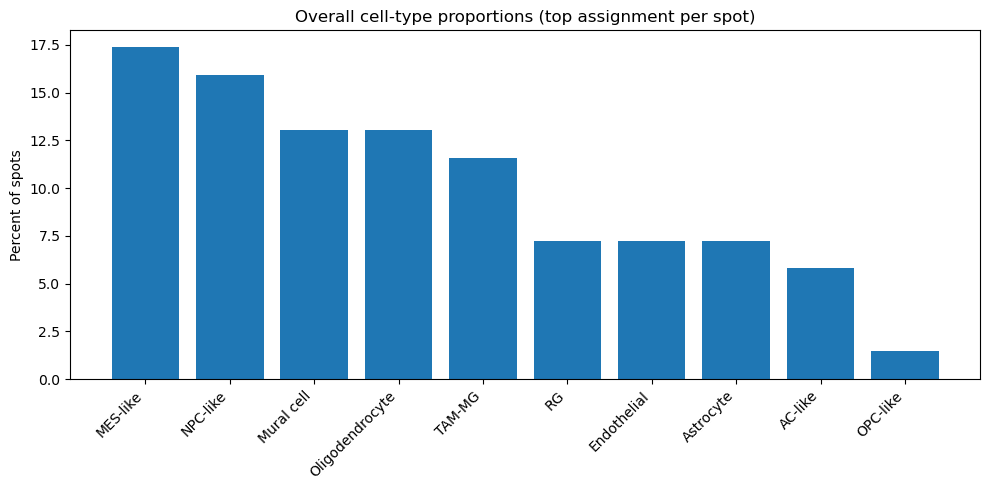

In [26]:
import matplotlib.pyplot as plt

overall_sorted = overall_props.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(overall_sorted.index, overall_sorted.values)
plt.ylabel("Percent of spots")
plt.title("Overall cell-type proportions (top assignment per spot)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
# plt.savefig("overall_celltype_proportions.png", dpi=300, bbox_inches="tight")


#### Dominant cell type per core — lollipop (mean weight)

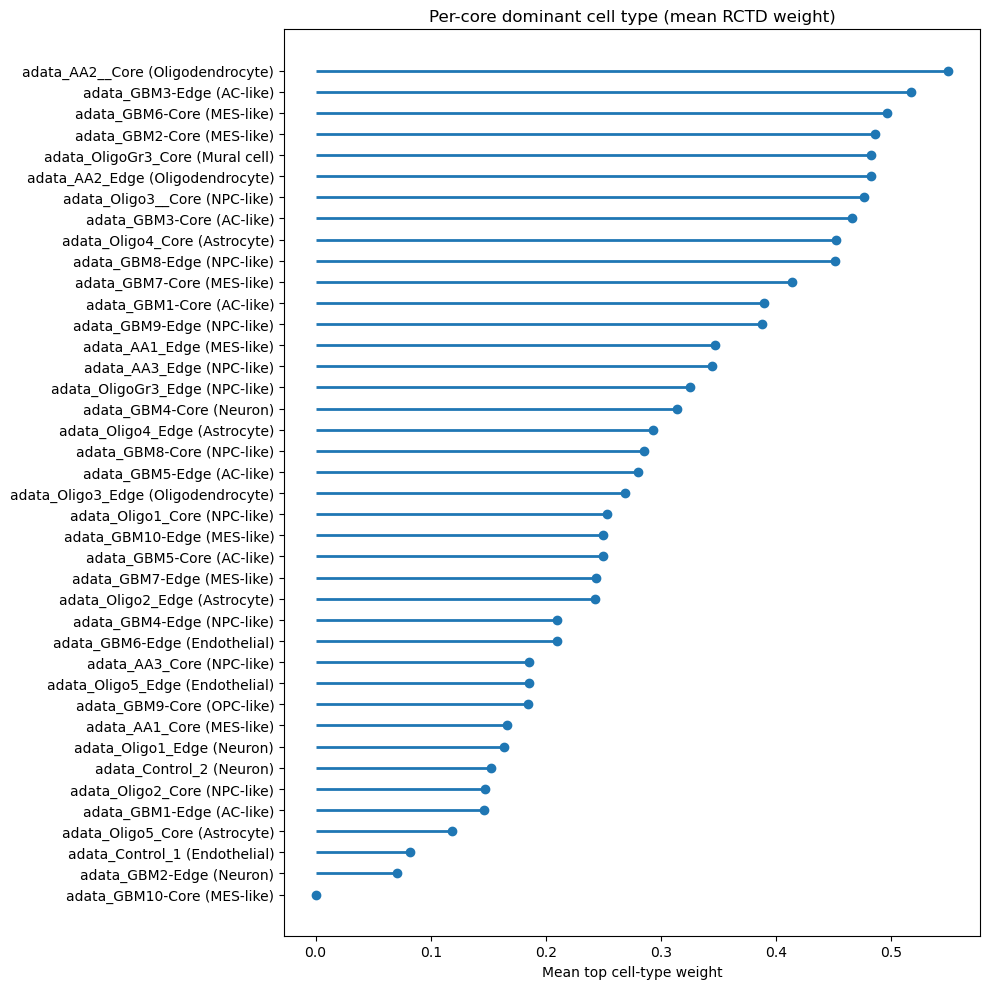

In [29]:
cs = core_summary.sort_values("mean_weight", ascending=False)

plt.figure(figsize=(10, 10))
y = range(len(cs))
plt.hlines(y=y, xmin=0, xmax=cs["mean_weight"], linewidth=2)
plt.plot(cs["mean_weight"], y, "o")
plt.yticks(y, [f"{c} ({t})" for c, t in zip(cs["core"], cs["top_cell_type"])])
plt.xlabel("Mean top cell-type weight")
plt.title("Per-core dominant cell type (mean RCTD weight)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
# plt.savefig("core_top_celltype_mean_weight.png", dpi=300, bbox_inches="tight")


#### Core × cell-type composition — 100% stacked bars

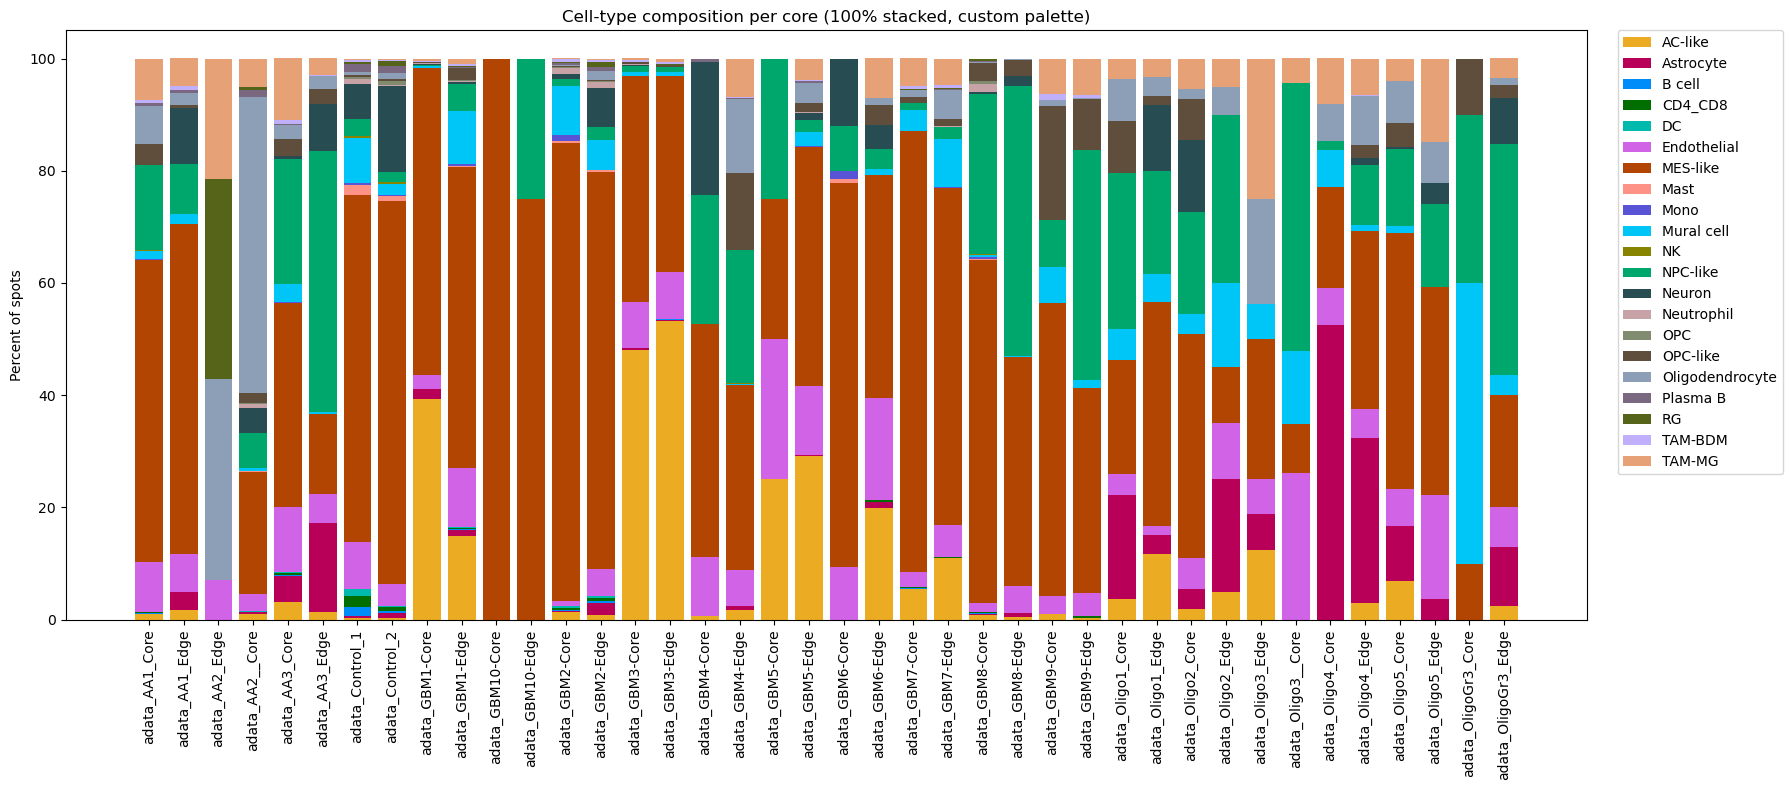

In [36]:
import matplotlib.pyplot as plt

# Your given palette
colors_palette = [
    '#ebac23', '#b80058', '#008cf9', '#006e00', '#00bbad', '#d163e6',
    '#b24502', '#ff9287', '#5954d6', '#00c6f8', '#878500', '#00a76c',
    '#274d52', '#c7a2a6', '#818b70', '#604e3c', '#8c9fb7', '#796880',
    '#56641a', '#c0affb', '#e6a176', '#00678a', '#984464', '#5eccab', '#bdbdbd'
]

# Ensure we have enough colors for all cell types
cell_types = core_props.columns.tolist()
color_map = {ct: colors_palette[i % len(colors_palette)] for i, ct in enumerate(cell_types)}

# Plot
plt.figure(figsize=(18, 8))
bottom = None
for ct in cell_types:
    vals = core_props[ct].values
    if bottom is None:
        plt.bar(core_props.index, vals, label=ct, color=color_map[ct])
        bottom = vals
    else:
        plt.bar(core_props.index, vals, bottom=bottom, label=ct, color=color_map[ct])
        bottom = bottom + vals

plt.ylabel("Percent of spots")
plt.title("Cell-type composition per core (100% stacked, custom palette)")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()


#### Heatmap — core × cell-type % 

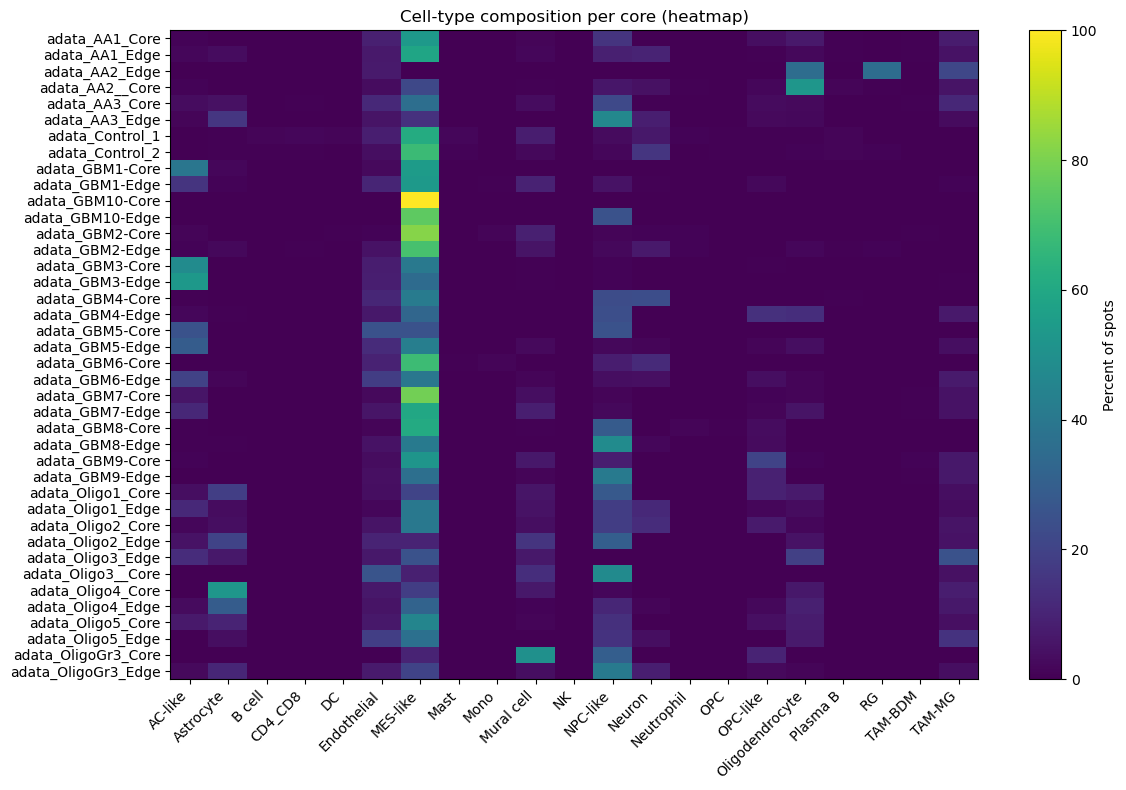

In [33]:
import numpy as np

mat = core_props.values
plt.figure(figsize=(12, 8))
im = plt.imshow(mat, aspect="auto")
plt.colorbar(im, label="Percent of spots")
plt.yticks(np.arange(core_props.shape[0]), core_props.index)
plt.xticks(np.arange(core_props.shape[1]), core_props.columns, rotation=45, ha="right")
plt.title("Cell-type composition per core (heatmap)")
plt.tight_layout()
plt.show()
# plt.savefig("core_celltype_composition_heatmap.png", dpi=300, bbox_inches="tight")


#### Robustness check — distribution of per-spot “top weight” by core

-shows how confident the assignments are within each core

/tmp/ipykernel_16394/1095010274.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


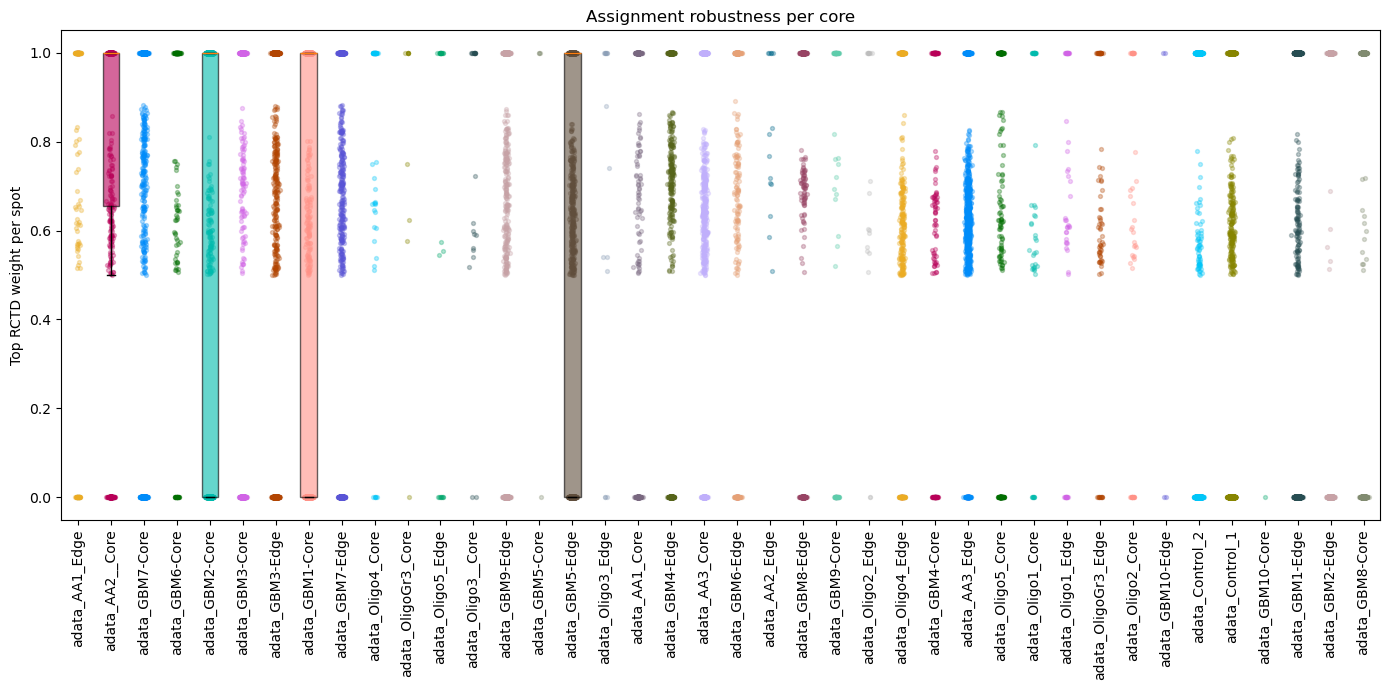

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Compute per-spot top weight
top_w = df[weight_cols].max(axis=1)
by_core = pd.DataFrame({"core": df["core"], "top_weight": top_w})

# Sort cores by median top weight
med = by_core.groupby("core")["top_weight"].median().sort_values(ascending=False)
order = med.index.tolist()

# Prepare color mapping for cores
color_map_core = {core: colors_palette[i % len(colors_palette)] for i, core in enumerate(order)}

plt.figure(figsize=(14, 7))

# Boxplots
box = plt.boxplot(
    [by_core.loc[by_core["core"] == c, "top_weight"].values for c in order],
    labels=order, patch_artist=True, showfliers=False
)

# Apply custom colors to boxes
for patch, core in zip(box['boxes'], order):
    patch.set_facecolor(color_map_core[core])
    patch.set_alpha(0.6)

# Overlay jittered points for better visibility
for i, core in enumerate(order, start=1):
    y_vals = by_core.loc[by_core["core"] == core, "top_weight"].values
    x_vals = np.random.normal(i, 0.04, size=len(y_vals))  # jitter
    plt.scatter(x_vals, y_vals, alpha=0.3, s=8, color=color_map_core[core])

plt.xticks(rotation=90)
plt.ylabel("Top RCTD weight per spot")
plt.title("Assignment robustness per core")
plt.tight_layout()
plt.show()


 To make robustness QC even faster to read, we can flag and color in a second layer the low-confidence cores , for example, any core with median top_weight < 0.25 will be marked in red.

/tmp/ipykernel_16394/30191197.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


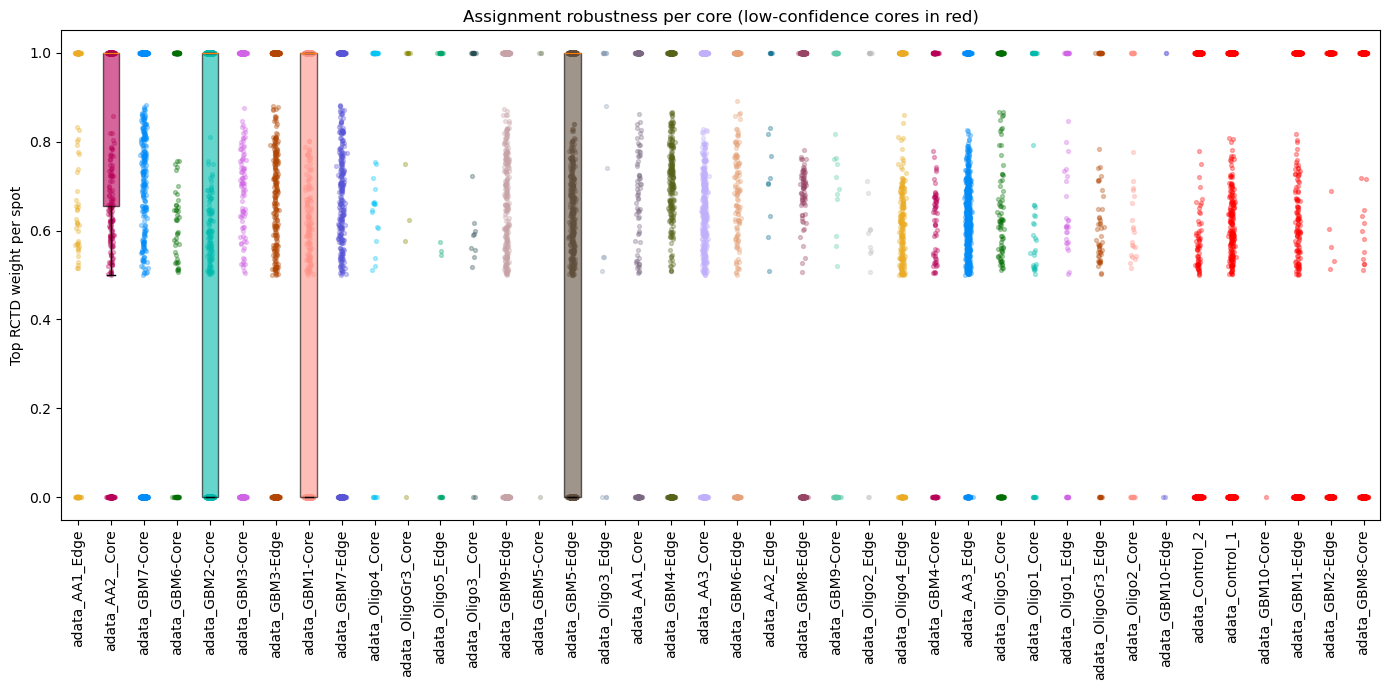

In [39]:
# Median top weight per core
medians = by_core.groupby("core")["top_weight"].median()

# Flag low-confidence cores
low_conf_cores = medians[medians < 0.25].index.tolist()

plt.figure(figsize=(14, 7))

box = plt.boxplot(
    [by_core.loc[by_core["core"] == c, "top_weight"].values for c in order],
    labels=order, patch_artist=True, showfliers=False
)

# Apply colors: red if low confidence, else from palette
for patch, core in zip(box['boxes'], order):
    if core in low_conf_cores:
        patch.set_facecolor("red")
        patch.set_alpha(0.5)
    else:
        patch.set_facecolor(color_map_core[core])
        patch.set_alpha(0.6)

# Overlay jittered points
for i, core in enumerate(order, start=1):
    y_vals = by_core.loc[by_core["core"] == core, "top_weight"].values
    x_vals = np.random.normal(i, 0.04, size=len(y_vals))
    plt.scatter(
        x_vals, y_vals,
        alpha=0.3, s=8,
        color="red" if core in low_conf_cores else color_map_core[core]
    )

plt.xticks(rotation=90)
plt.ylabel("Top RCTD weight per spot")
plt.title("Assignment robustness per core (low-confidence cores in red)")
plt.tight_layout()
plt.show()


### QC done-moving forward to cell-type proportions calculation and other downstraem analysis

In [40]:
import re
import pandas as pd

# 1) load (if not already)
# df = pd.read_csv("rctd-adatas.csv")

# RCTD weight columns
weight_cols = [c for c in df.columns if c.startswith("rctd_wt_")]

# Top assignment for each spot
top_assign = df[weight_cols].idxmax(axis=1).str.replace("rctd_wt_", "", regex=False)

# Helper parsers from the `core` string
def parse_tumor(s):
    m = re.search(r"(GBM|AA|Oligo|Control)", s, re.I)
    return m.group(1).upper().replace("OLIGO","Oligo") if m else "Unknown"

def parse_site(s):
    m = re.search(r"(Core|Edge|Control)", s, re.I)
    return m.group(1).capitalize() if m else "Unknown"

# Build tidy frame
tidy = pd.DataFrame({
    "sample": df["core"],                      # keep your core name as sample
    "tumor_type": df["core"].map(parse_tumor),
    "site": df["core"].map(parse_site),
    "cell_type": top_assign
})


/tmp/ipykernel_16394/2806175586.py:11: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  top_assign = df[weight_cols].idxmax(axis=1).str.replace("rctd_wt_", "", regex=False)


In [42]:
# counts per sample × cell_type
counts = (
    tidy.groupby(["sample", "tumor_type", "site", "cell_type"])
        .size()
        .rename("n")
        .reset_index()
)

# convert to % within each sample
counts["proportion"] = counts["n"] / counts.groupby("sample")["n"].transform("sum") * 100

# final tidy table
df_ctype2 = counts[["proportion","sample","tumor_type","cell_type","site"]].sort_values(
    ["sample","proportion"], ascending=[True, False]
)

print(df_ctype2.head())


    proportion          sample tumor_type        cell_type  site
4    53.846154  adata_AA1_Core         AA         MES-like  Core
8    15.151515  adata_AA1_Core         AA         NPC-like  Core
3     8.857809  adata_AA1_Core         AA      Endothelial  Core
13    7.459207  adata_AA1_Core         AA           TAM-MG  Core
10    6.759907  adata_AA1_Core         AA  Oligodendrocyte  Core


In [43]:
sample_ct_pct = (
    df_ctype2.pivot_table(index=["sample","tumor_type","site"],
                          columns="cell_type", values="proportion",
                          fill_value=0.0)
    .reset_index()
)
print(sample_ct_pct.head())


cell_type           sample tumor_type  site   AC-like  Astrocyte    B cell  \
0           adata_AA1_Core         AA  Core  0.932401   0.000000  0.233100   
1           adata_AA1_Edge         AA  Edge  1.666667   3.333333  0.000000   
2           adata_AA2_Edge         AA  Edge  0.000000   0.000000  0.000000   
3          adata_AA2__Core         AA  Core  0.919963   0.367985  0.091996   
4           adata_AA3_Core         AA  Core  3.174603   4.662698  0.099206   

cell_type   CD4_CD8        DC  Endothelial   MES-like      Mast      Mono  \
0          0.233100  0.000000     8.857809  53.846154  0.000000  0.233100   
1          0.000000  0.000000     6.666667  58.888889  0.000000  0.000000   
2          0.000000  0.000000     7.142857   0.000000  0.000000  0.000000   
3          0.000000  0.091996     3.127875  21.803128  0.091996  0.000000   
4          0.396825  0.198413    11.507937  36.309524  0.000000  0.198413   

cell_type  Mural cell      NK   NPC-like     Neuron  Neutrophil     

In [44]:
site_order = {"Core":0, "Edge":1, "Control":2, "Unknown":99}
tumor_order = {"GBM":0, "AA":1, "Oligo":2, "Control":3, "Unknown":99}

df_ctype2["site_ord"] = df_ctype2["site"].map(site_order).fillna(99)
df_ctype2["tumor_ord"] = df_ctype2["tumor_type"].map(tumor_order).fillna(99)

df_ctype2 = df_ctype2.sort_values(["tumor_ord","site_ord","sample","proportion"], ascending=[True,True,True,False]).drop(columns=["site_ord","tumor_ord"])


In [ ]:
df_ctype2.to_csv("celltype_proportions_per_sample_tidy.csv", index=False)
sample_ct_pct.to_csv("celltype_proportions_per_sample_wide.csv", index=False)


In [ ]:
df_ctype2

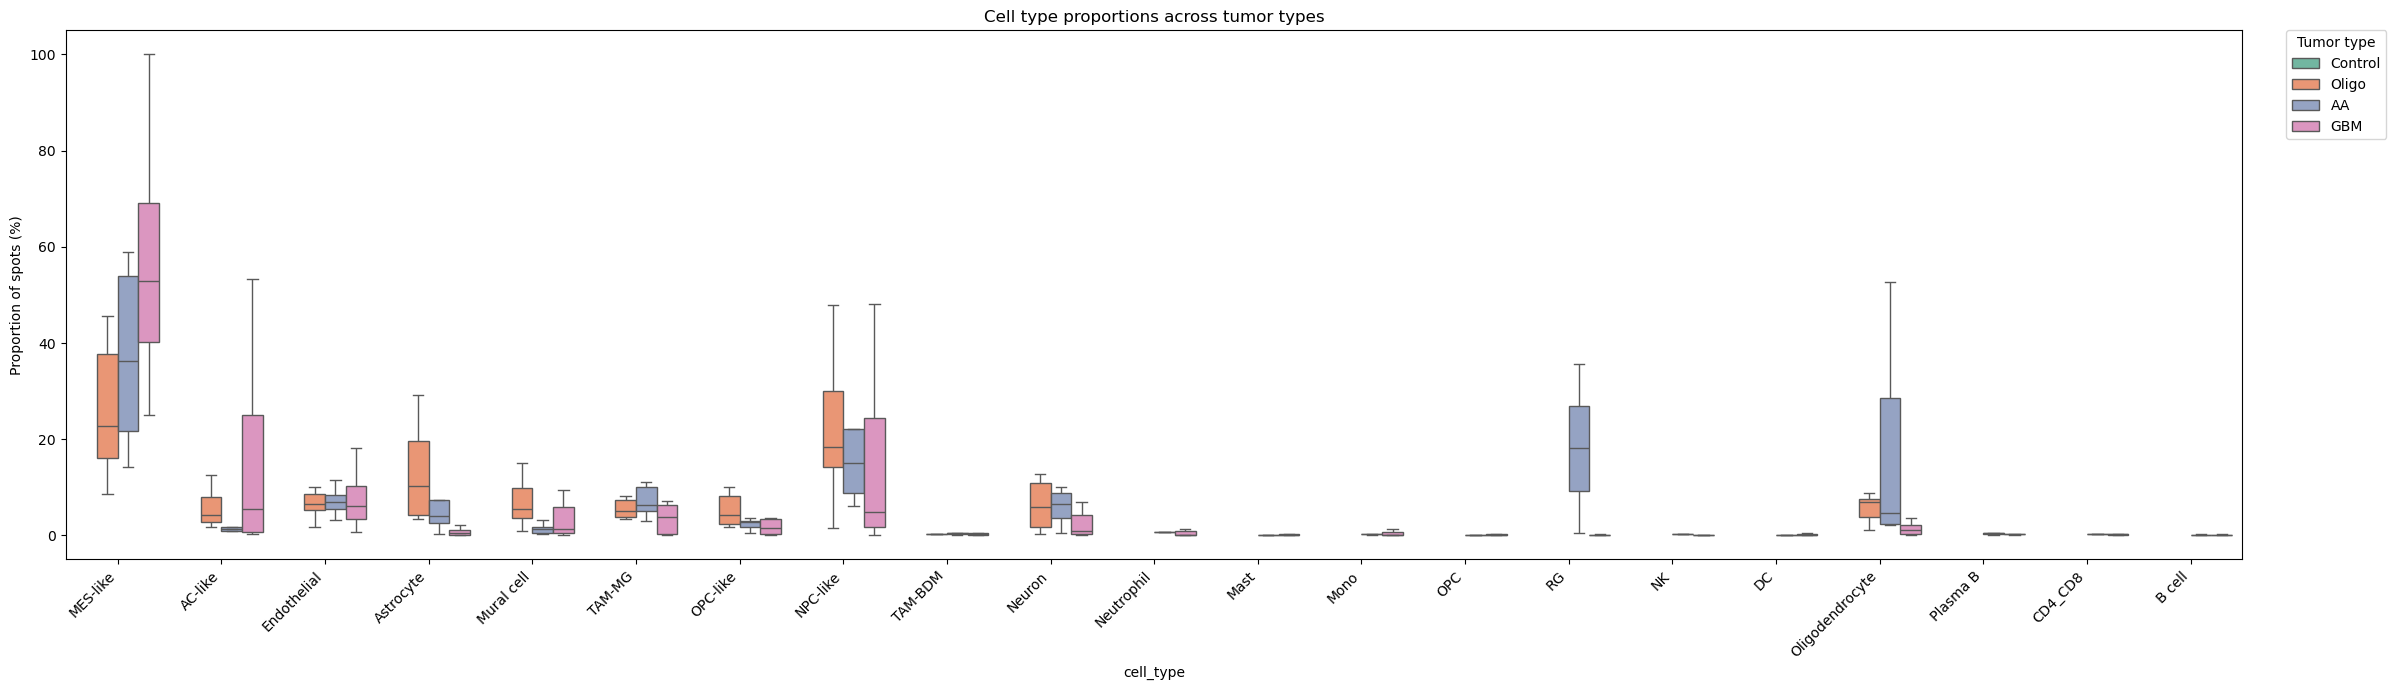

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure data is in correct numeric type
df_ctype2["proportion"] = pd.to_numeric(df_ctype2["proportion"], errors="coerce")

# Unique cell types for consistent coloring
cell_types = sorted(df_ctype2["cell_type"].unique())
color_map_ct = {ct: colors_palette[i % len(colors_palette)] for i, ct in enumerate(cell_types)}

plt.figure(figsize=(24, 7))
sns.boxplot(
    data=df_ctype2,
    x="cell_type",
    y="proportion",
    hue="tumor_type",
    palette="Set2",  # tumor type coloring (not cell type)
    showfliers=False
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of spots (%)")
plt.title("Cell type proportions across tumor types")
plt.legend(title="Tumor type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.show()


/tmp/ipykernel_16394/1592716742.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_16394/1592716742.py:36: UserWarning: The palette list has more values (25) than needed (4), which may not be intended.
  sns.stripplot(
/tmp/ipykernel_16394/1592716742.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16394/1592716742.py:42: UserWarning: The palette list has more values (25) than needed (4), which may not be intended.
  sns.boxplot(
/tmp/ipykernel_16394/1592716742.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  

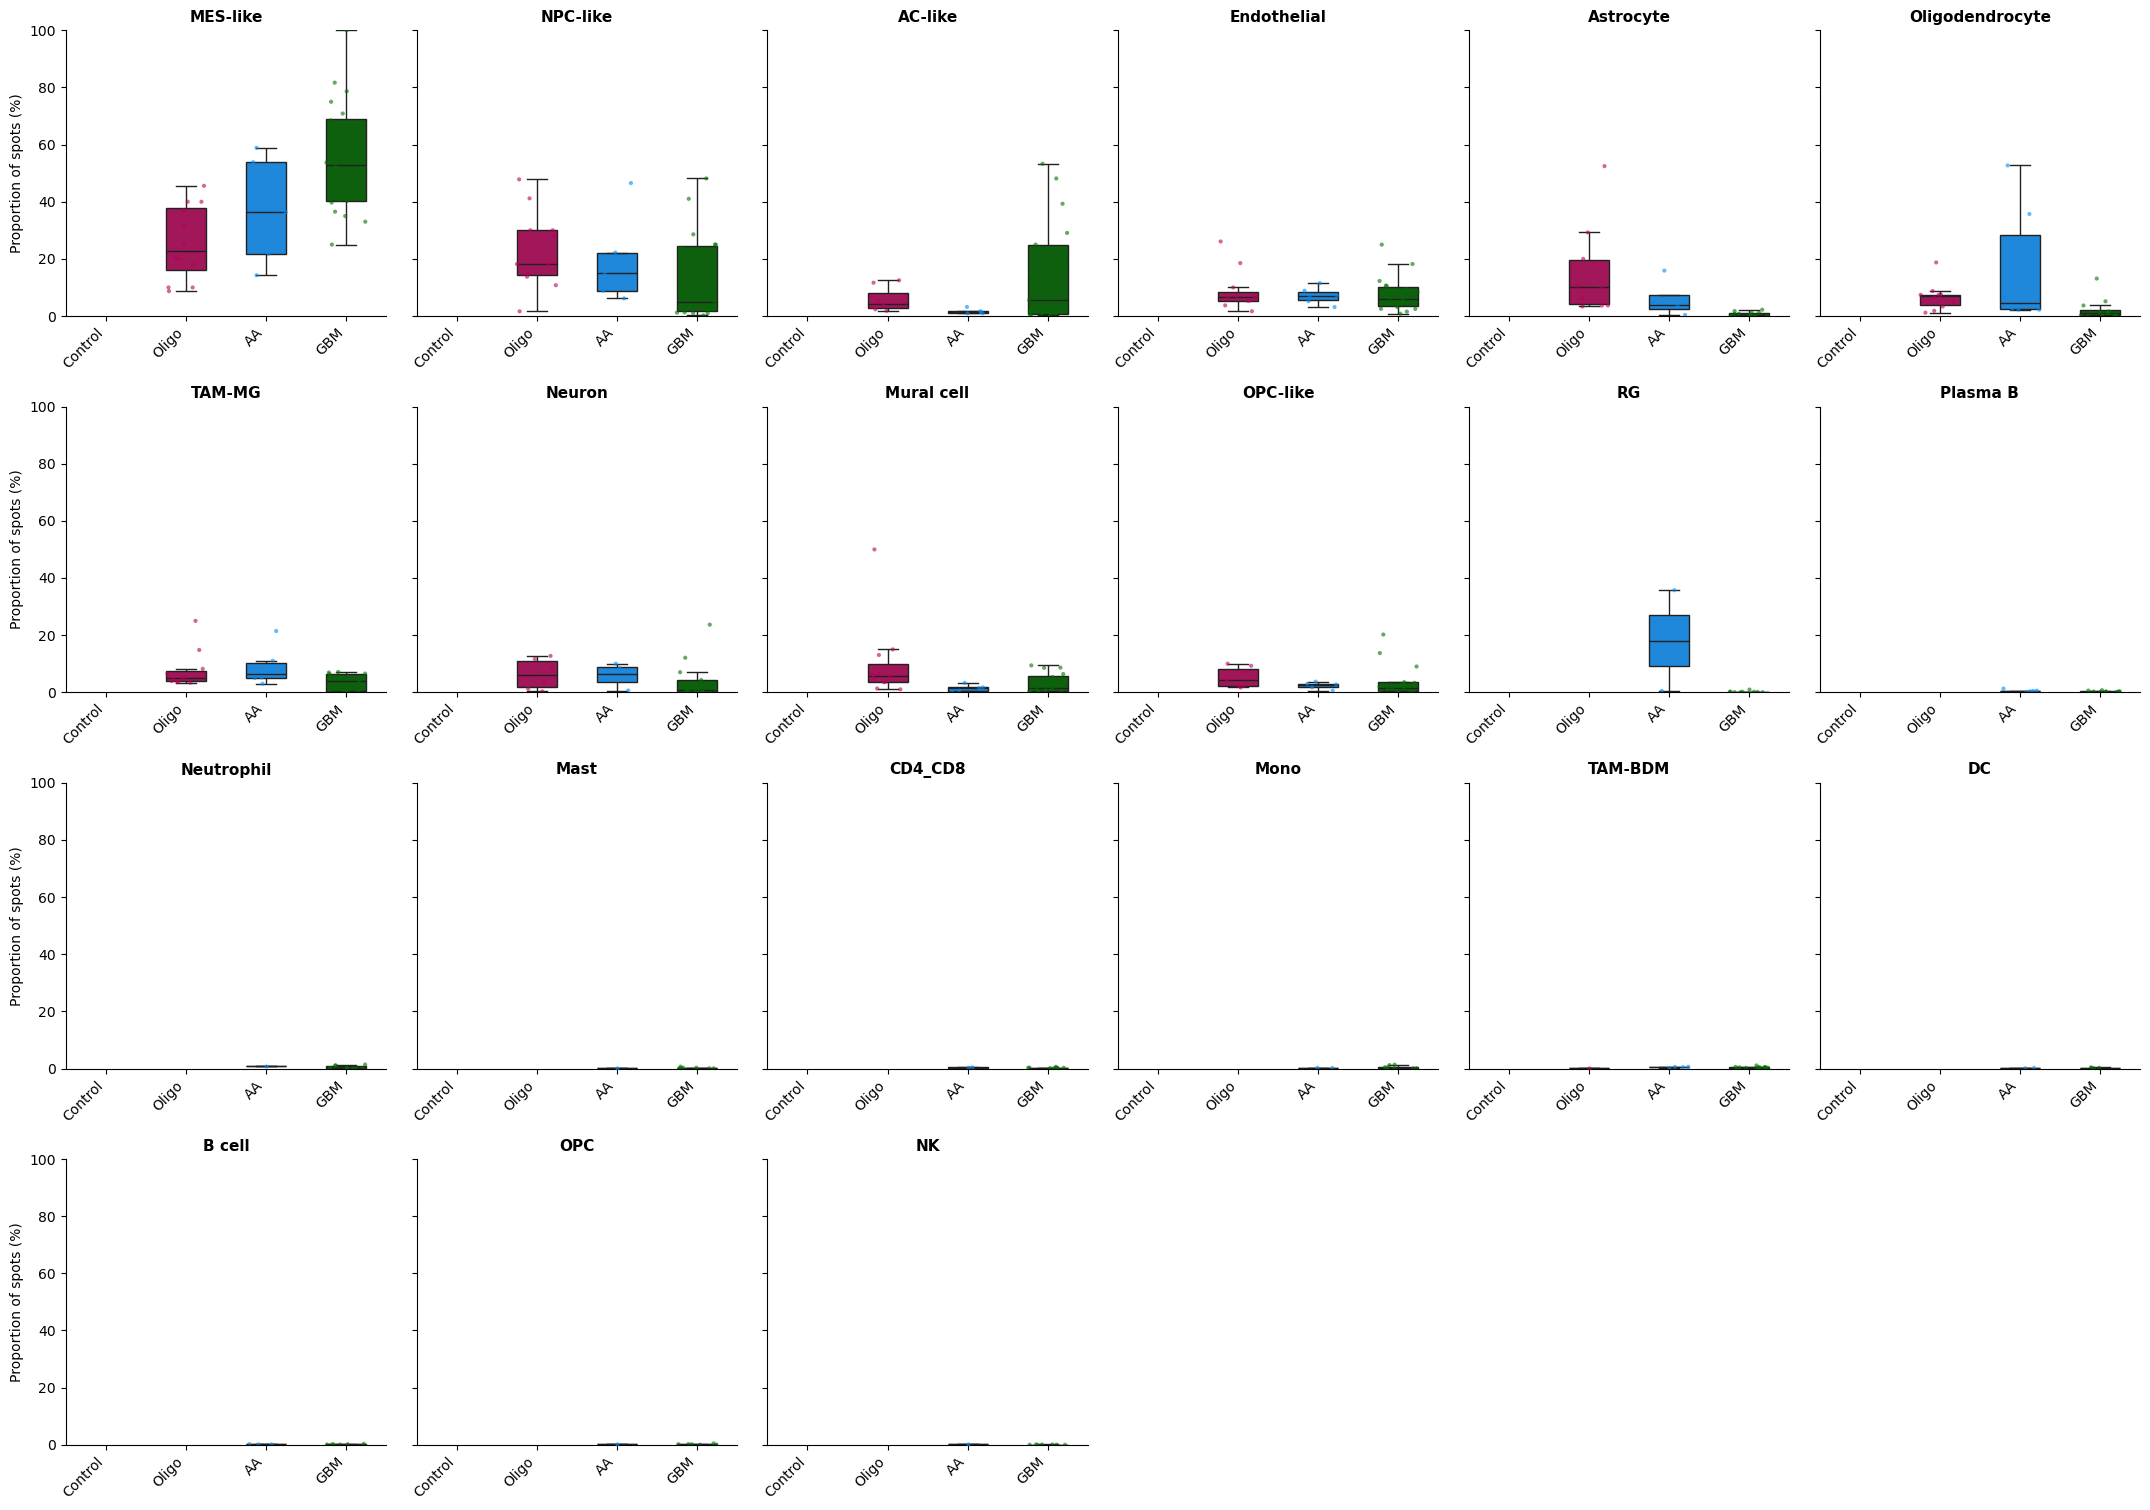

In [50]:
# --- INPUTS expected ---
# df_ctype2: tidy table with columns ["proportion","sample","tumor_type","cell_type","site"]
# colors_palette: your 25-color list

import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 0) clean types & orders
df_ctype2 = df_ctype2.copy()
df_ctype2["proportion"] = pd.to_numeric(df_ctype2["proportion"], errors="coerce")

tumor_order = ["Control", "Oligo", "AA", "GBM"]  # change if you prefer
df_ctype2["tumor_type"] = pd.Categorical(df_ctype2["tumor_type"], categories=tumor_order, ordered=True)

# order cell types by overall mean proportion (desc)
ctype_order = (
    df_ctype2.groupby("cell_type")["proportion"].mean().sort_values(ascending=False).index.tolist()
)
df_ctype2["cell_type"] = pd.Categorical(df_ctype2["cell_type"], categories=ctype_order, ordered=True)

# 1) grid setup
n_ct = len(ctype_order)
ncols = 6                                # tweak columns per row
nrows = math.ceil(n_ct / ncols)
fig, ax = plt.subplots(nrows, ncols, figsize=(3.6*ncols, 3.8*nrows), sharey=True)
ax = ax.flatten()

# 2) draw each cell type panel
for i, ctype in enumerate(ctype_order):
    a = ax[i]
    sub = df_ctype2[df_ctype2["cell_type"] == ctype]

    # points
    sns.stripplot(
        data=sub, x="tumor_type", y="proportion",
        ax=a, jitter=0.25, size=3, alpha=0.6,
        palette=colors_palette  # colors per tumor category
    )
    # boxes
    sns.boxplot(
        data=sub, x="tumor_type", y="proportion",
        ax=a, showcaps=True, showfliers=False, width=0.5,
        palette=colors_palette
    )

    a.set_title(ctype, fontsize=11, fontweight="bold")
    a.set_xlabel("")
    if i % ncols == 0:
        a.set_ylabel("Proportion of spots (%)")
    else:
        a.set_ylabel("")

    a.set_ylim(0, 100)                   # proportions are in %
    a.legend_.remove() if a.get_legend() else None
    plt.setp(a.xaxis.get_majorticklabels(), rotation=45, ha="right")

# 3) turn off any empty panels
for j in range(i+1, len(ax)):
    ax[j].axis("off")

sns.despine()
plt.tight_layout()
plt.show()
# save if you want:
# fig.savefig(save_figure_path + "/cell_type_proportions_across_tumors.png", dpi=300, bbox_inches="tight")


#### Reason for above boxplots:   
A spot with 0.55 MES‑like + 0.30 TAM‑MG + 0.15 Endothelial will be 100% MES‑like under argmax, but weights‑sum gives 55/30/15%. In tumor‑dense regions this makes a huge difference.

In [56]:
import pandas as pd

# assumes df and weight_cols already defined
# sample-wise total weight per cell type
w_sum = (df.groupby("core")[weight_cols].sum())

# convert to percentage per sample (rows sum to 100)
w_pct = w_sum.div(w_sum.sum(axis=1), axis=0) * 100

# tidy for plotting
w_tidy = (
    w_pct.reset_index()
         .melt(id_vars="core", var_name="cell_type", value_name="proportion")
)
w_tidy["cell_type"] = w_tidy["cell_type"].str.replace("rctd_wt_", "", regex=False)


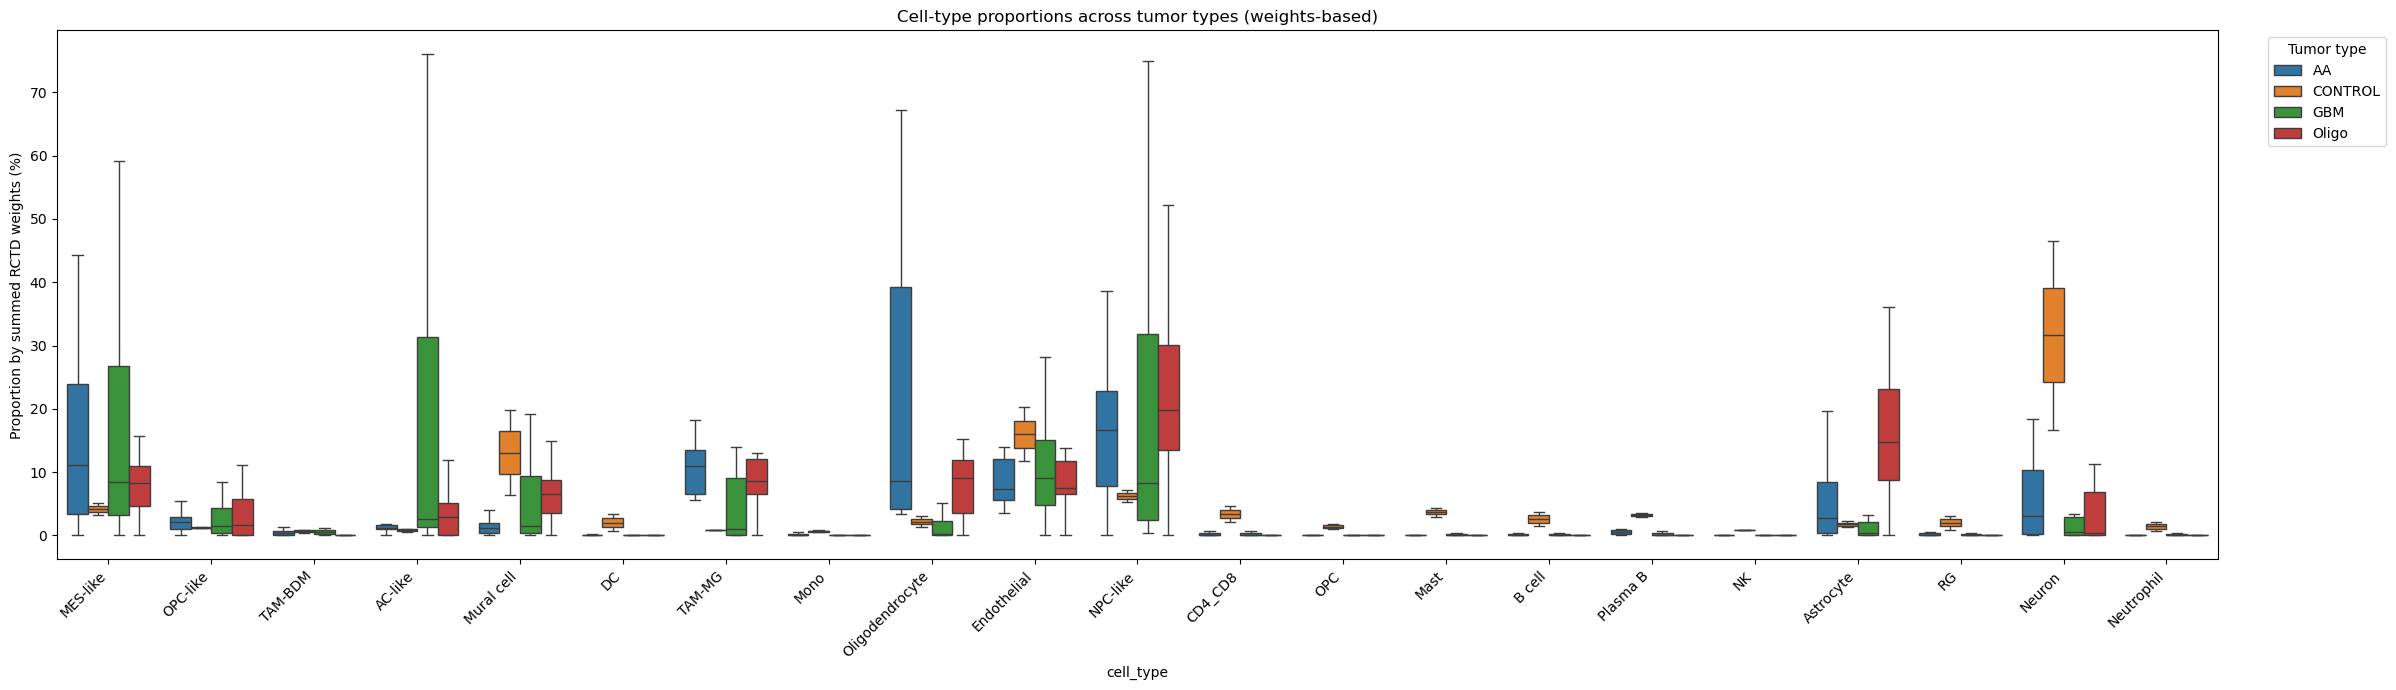

In [59]:
import re
def parse_tumor(s):
    m = re.search(r"(GBM|AA|Oligo|Control)", s, re.I)
    return m.group(1).upper().replace("OLIGO","Oligo") if m else "Unknown"
def parse_site(s):
    m = re.search(r"(Core|Edge|Control)", s, re.I)
    return m.group(1).capitalize() if m else "Unknown"

meta = w_tidy.copy()
meta["tumor_type"] = meta["core"].map(parse_tumor)
meta["site"]       = meta["core"].map(parse_site)

# BOX: cell-type proportions across tumor types (weights-based)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(24,7))
sns.boxplot(
    data=meta, x="cell_type", y="proportion",
    hue="tumor_type", showfliers=False
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion by summed RCTD weights (%)")
plt.title("Cell-type proportions across tumor types (weights-based)")
plt.legend(title="Tumor type", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


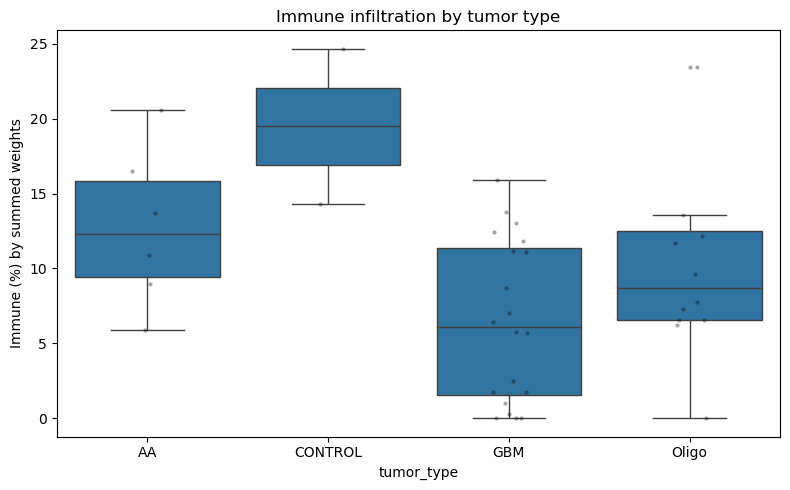

In [58]:
immune_types = [
    "TAM-MG","TAM-BDM","Mono","DC","B cell","Plasma B",
    "CD4_CD8","NK","Neutrophil","Mast"
]

# collapse to immune vs non-immune at sample level
w_pct_named = w_pct.copy()
w_pct_named.columns = [c.replace("rctd_wt_","") for c in w_pct_named.columns]

immune_pct = w_pct_named[immune_types].sum(axis=1).rename("immune_percent").reset_index()
immune_pct["tumor_type"] = immune_pct["core"].map(parse_tumor)
immune_pct["site"]       = immune_pct["core"].map(parse_site)

# boxplots
plt.figure(figsize=(8,5))
sns.boxplot(data=immune_pct, x="tumor_type", y="immune_percent", showfliers=False)
sns.stripplot(data=immune_pct, x="tumor_type", y="immune_percent", color="k", alpha=0.35, size=3)
plt.ylabel("Immune (%) by summed weights")
plt.title("Immune infiltration by tumor type")
plt.tight_layout(); plt.show()


In [60]:
# keep confident spots (tune threshold)
thr = 0.9
keep = df["singlet_score"] >= thr

w_sum_f = df.loc[keep].groupby("core")[weight_cols].sum()
w_pct_f = w_sum_f.div(w_sum_f.sum(axis=1), axis=0) * 100
immune_pct_f = (
    w_pct_f.rename(columns=lambda c: c.replace("rctd_wt_",""))[immune_types]
           .sum(axis=1).rename(f"immune_percent_score>{thr}")
)
print(immune_pct_f.describe())


count     7.000000
mean      6.356654
std       9.212065
min       0.000000
25%       0.000000
50%       0.000000
75%      10.521985
max      23.452606
Name: immune_percent_score>0.9, dtype: float64


In [61]:
# Do weights sum to ~1 per spot?
w_row_sum = df[weight_cols].sum(axis=1)
print(w_row_sum.describe())

# If far from 1, normalize before aggregation:
norm_w = df[weight_cols].div(w_row_sum.replace(0, 1), axis=0)
w_pct_norm = norm_w.groupby(df["core"]).sum()
w_pct_norm = w_pct_norm.div(w_pct_norm.sum(axis=1), axis=0) * 100


count    169574.000000
mean          0.179096
std           0.383004
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
dtype: float64


Filter spots by singlet_score > 0.9.

Summed-weight proportions per sample.

Extract immune subtypes →

Boxplot of total immune % per tumor type.

Subtype breakdown (Myeloid, T, B, NK, etc.) per tumor type.

Sample × immune subtype heatmap

In [66]:
# Filter by score
thr = 0.2
keep = df["singlet_score"] >= thr

# Summed weights per sample
w_sum = df.loc[keep].groupby("core")[weight_cols].sum()

# Percentages
w_pct = w_sum.div(w_sum.sum(axis=1), axis=0) * 100

# Rename columns
w_pct.columns = w_pct.columns.str.replace("rctd_wt_", "", regex=False)

# Add metadata
w_pct = w_pct.reset_index()
w_pct["tumor_type"] = w_pct["core"].map(parse_tumor)
w_pct["site"] = w_pct["core"].map(parse_site)


#### Total immmune % per tumor type

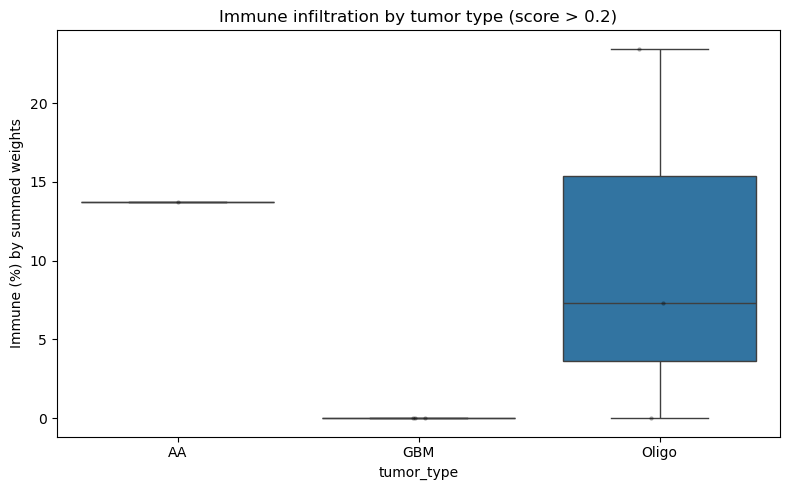

In [67]:
immune_types = [
    "TAM-MG","TAM-BDM","Mono","DC","B cell","Plasma B",
    "CD4_CD8","NK","Neutrophil","Mast"
]

immune_pct = (
    w_pct[["core", "tumor_type", "site"] + immune_types]
    .assign(immune_percent=lambda x: x[immune_types].sum(axis=1))
)

plt.figure(figsize=(8,5))
sns.boxplot(data=immune_pct, x="tumor_type", y="immune_percent", showfliers=False)
sns.stripplot(data=immune_pct, x="tumor_type", y="immune_percent", color="k", alpha=0.35, size=3)
plt.ylabel("Immune (%) by summed weights")
plt.title(f"Immune infiltration by tumor type (score > {thr})")
plt.tight_layout(); plt.show()


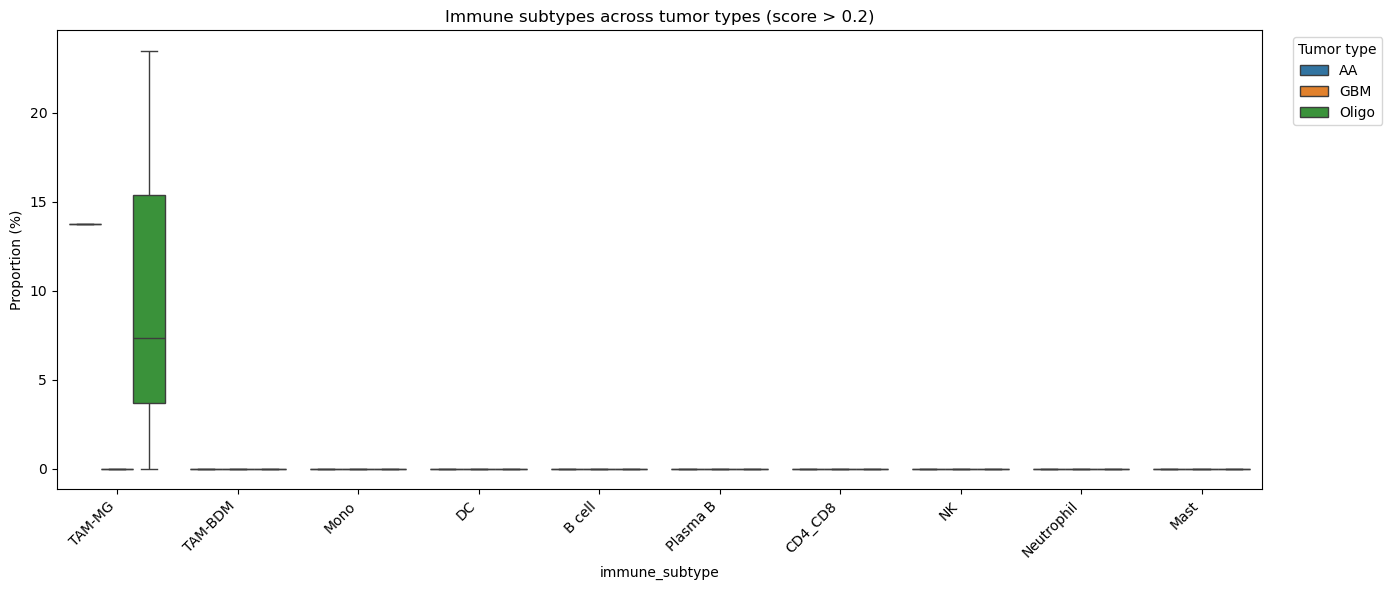

In [68]:
immune_tidy = (
    immune_pct.melt(id_vars=["core","tumor_type","site"], value_vars=immune_types,
                    var_name="immune_subtype", value_name="proportion")
)

plt.figure(figsize=(14,6))
sns.boxplot(data=immune_tidy, x="immune_subtype", y="proportion", hue="tumor_type", showfliers=False)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion (%)")
plt.title(f"Immune subtypes across tumor types (score > {thr})")
plt.legend(title="Tumor type", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


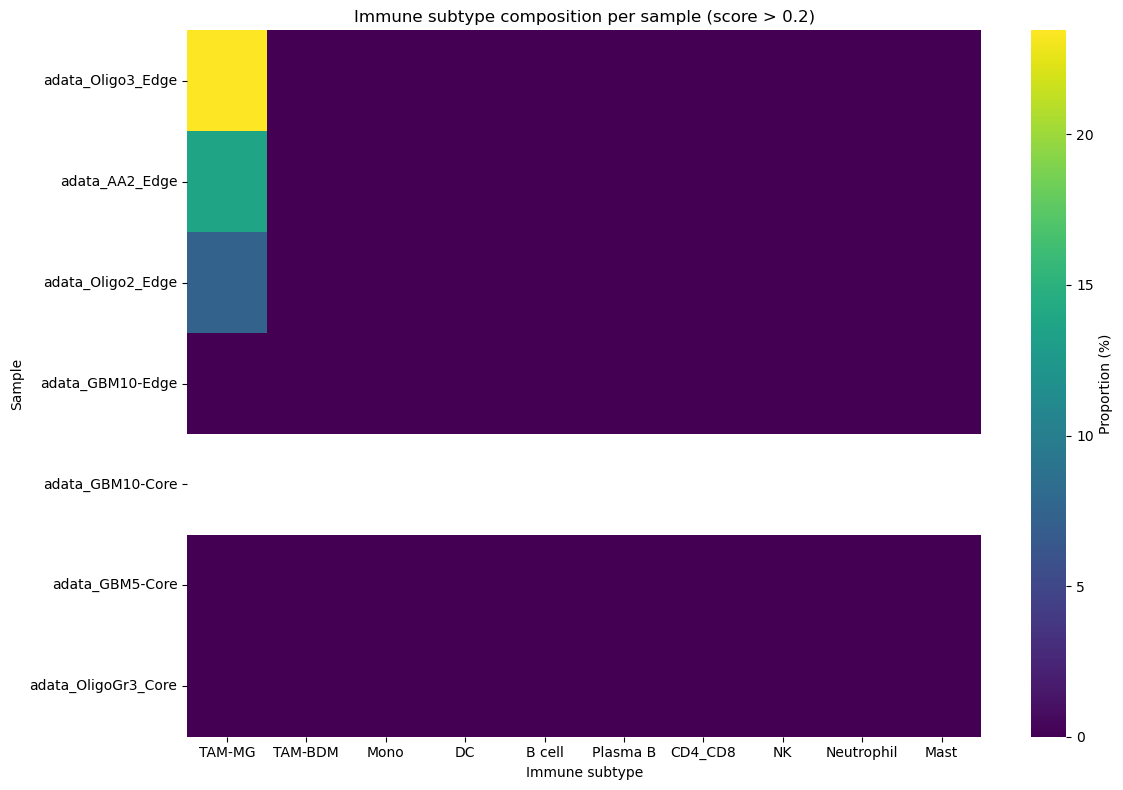

In [69]:
import seaborn as sns

heat_df = immune_pct.set_index("core")[immune_types]
heat_df = heat_df.loc[heat_df.sum(axis=1).sort_values(ascending=False).index]  # order by total immune

plt.figure(figsize=(12,8))
sns.heatmap(heat_df, cmap="viridis", annot=False, cbar_kws={'label': 'Proportion (%)'})
plt.title(f"Immune subtype composition per sample (score > {thr})")
plt.ylabel("Sample")
plt.xlabel("Immune subtype")
plt.tight_layout(); plt.show()


## DEA 

In [74]:
import pandas as pd, numpy as np, scanpy as sc, re
from pathlib import Path

# path to your combined CSV (the one we used earlier)
rctd_df = adata_all.obs.copy()

# Normalize key columns
rctd_df.rename(columns={"Unnamed: 0":"cell_id"}, inplace=True)  # if present
rctd_df["cell_id"] = rctd_df["cell_id"].astype(str)


In [2]:
import re, numpy as np, pandas as pd, scanpy as sc
from pathlib import Path

# ====== CONFIG ======
AD_DIR = "/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/adatas_with_rctd/"
rctd_df = rctd_df  # already loaded CSV
SCORE_MIN, TOPW_MIN, MIN_CELLS, TOP_K = 0.90, 0.30, 4, 30

# ====== TINY HELPERS ======
def norm_core(fn: str) -> str:
    """Normalize filename -> sample key like 'AA1_Core'."""
    k = Path(fn).name.replace(".h5ad","")
    k = re.sub(r'(__.*|_with_rctd.*)$', '', k)      # drop suffixes
    return k.replace('-', '_')

def guess_csv_core(sample_key: str, choices: set[str]) -> str|None:
    """Map filename-derived key to CSV 'core' values (e.g. 'adata_*')."""
    variants = [
        sample_key,
        f"adata_{sample_key}",
        sample_key.replace('_Core','-Core').replace('_Edge','-Edge'),
        f"adata_{sample_key.replace('_Core','-Core').replace('_Edge','-Edge')}",
    ]
    for v in variants:
        if v in choices: return v
    # loose fallback
    hits = [c for c in choices if sample_key in c]
    return hits[0] if len(hits)==1 else None

def harmonize_ids(s: pd.Series) -> pd.Series:
    """Make IDs merge-friendly: strip trailing '-1', trim."""
    return s.astype(str).str.replace(r"-1$","",regex=True).str.strip()

def weight_cols(cols) -> list[str]:
    return [c for c in cols if c.startswith("rctd_w_") or c.startswith("rctd_wt_")]

# ====== MAIN ======
all_csv_cores = set(rctd_df["core"].astype(str).unique())
out = []

for h5 in sorted(Path(AD_DIR).glob("*.h5ad")):
    k = norm_core(h5.name)                     # e.g. AA1_Core
    csvk = guess_csv_core(k, all_csv_cores)
    if not csvk:
        print(f"[skip] no CSV core match for {k}"); 
        continue

    sub = rctd_df[rctd_df["core"] == csvk].copy()
    if "cell_id" not in sub.columns:
        sub["cell_id"] = sub.index.astype(str)
    # unify weight prefixes
    sub.columns = [c.replace("rctd_wt_","rctd_w_") for c in sub.columns]
    wc = weight_cols(sub.columns)
    if not wc:
        print(f"[skip] no rctd_w_* cols for {csvk}"); 
        continue

    # --- load AnnData & build join indices
    ad = sc.read_h5ad(h5)
    csv_norm = harmonize_ids(sub["cell_id"])
    obs_norm = harmonize_ids(pd.Series(ad.obs_names, index=ad.obs_names))
    # map normalized -> real obs_names
    obs_map = pd.Series(obs_norm.index, index=obs_norm.values)
    # direct intersect on normalized IDs
    inter = pd.Index(csv_norm).intersection(obs_norm.values)
    sub_idx = sub.set_index(csv_norm)

    # if none, try prefixing sample key (some pipelines store IDs without sample prefix)
    if len(inter) == 0:
        sub_idx.index = k + "_" + sub_idx.index
        inter = sub_idx.index.intersection(obs_norm.values)
        if len(inter) == 0:
            print(f"[skip] no matching barcodes for {csvk}"); 
            continue

    # map back to real AnnData obs_names for assignment
    real_obs = obs_map.loc[inter].values
    take = sub_idx.loc[inter]

    # inject weights (+ score if present)
    for c in wc:
        if c not in ad.obs: ad.obs[c] = np.nan
    ad.obs.loc[real_obs, wc] = take[wc].values
    if "singlet_score" in take.columns:
        if "singlet_score" not in ad.obs: ad.obs["singlet_score"] = np.nan
        ad.obs.loc[real_obs, "singlet_score"] = take["singlet_score"].values

    # --- RCTD top label + filters
    W = ad.obs[wc].astype(float).fillna(0.0)
    top_idx = W.values.argmax(axis=1)
    ad.obs["rctd_top_ct"]     = pd.Categorical([wc[i].replace("rctd_w_","") for i in top_idx])
    ad.obs["rctd_top_weight"] = W.values.max(axis=1)
    ad.obs["rctd_score"]      = ad.obs.get("singlet_score", pd.Series(1.0, index=ad.obs_names)).astype(float)

    keep = (ad.obs["rctd_top_weight"] >= TOPW_MIN) & (ad.obs["rctd_score"] >= SCORE_MIN)
    ad = ad[keep].copy()
    grp_sizes = ad.obs["rctd_top_ct"].value_counts()
    big = grp_sizes[grp_sizes >= MIN_CELLS].index
    if ad.n_obs == 0 or len(big) < 2:
        print(f"[skip] too few cells/groups in {k}")
        continue
    ad = ad[ad.obs["rctd_top_ct"].isin(big)].copy()

    # --- DGE (Wilcoxon), tidy, keep top-30 per (sample, cell_type)
    sc.tl.rank_genes_groups(ad, groupby="rctd_top_ct", method="wilcoxon",
                            n_genes=max(TOP_K, 60), rankby_abs=True,
                            tie_correct=True, corr_method="benjamini-hochberg", pts=True)

    rg = sc.get.rank_genes_groups_df(ad, group=None)  # all groups stacked
    rg = rg.rename(columns={"group":"cell_type"})
    rg["sample"]     = k
    rg["tumor_type"] = re.sub(r"\d+","", k.split("_")[0]).replace("OligoGr","Oligo")
    rg["site"]       = (k.split("_")[1] if "_" in k else "Unknown")

    out.append(
        rg.sort_values(["cell_type","scores"], ascending=[True, False])
          .groupby(["cell_type"], as_index=False).head(TOP_K)
    )

# ====== SAVE ======
res = pd.concat(out, ignore_index=True) if out else pd.DataFrame()
res.to_csv("rctd_rank_genes_top30_per_ct_per_sample.csv", index=False)
print("DONE:", res.shape, "-> rctd_rank_genes_top30_per_ct_per_sample.csv")


NameError: name 'rctd_df' is not defined